### 1) Merging RaCA

In [15]:
#Load Main Dataset

import pandas as pd

df = pd.read_csv("RaCA_2.0/RaCA_2025.xlsx - RaCA_SOC_pedons.csv")  

# Check if 'upedonid' is unique
is_upedonid_unique = df['upedonid'].is_unique
print("Is 'upedonid' unique?", is_upedonid_unique)

# Check if 'rcasiteid' is unique
is_rcasiteid_unique = df['rcasiteid'].is_unique
print("\nIs 'rcasiteid' unique?", is_rcasiteid_unique)

print(df.shape)

Is 'upedonid' unique? True

Is 'rcasiteid' unique? True
(6236, 18)


In [16]:
#Load and merge date

# Load the datasets
date_df = pd.read_csv("RaCA_2.0/RaCA_2025.xlsx - RaCA_sample date.csv")

# --- Check uniqueness in date_df ---
# is_userpedonid_unique = date_df['userpedonid'].is_unique
# print("Is 'userpedonid' unique?", is_userpedonid_unique)

# is_rcasiteid_unique_date = date_df['rcasiteid'].is_unique
# print("Is 'rcasiteid' unique in date_df?", is_rcasiteid_unique_date)

date_df = date_df.drop(columns=['rcasiteid'])

# --- Join date_df into df ---
merged_df = df.merge(
    date_df,
    left_on='upedonid',
    right_on='userpedonid',
    how='left'
)

print("\nMerged dataframe shape:", merged_df.shape)
# print(merged_df.columns)


Merged dataframe shape: (6306, 20)


In [14]:
# Find rows where there was no match in date_df
unmatched = merged_df[merged_df['userpedonid'].isna()]

print("Number of unmatched upedonid:", len(unmatched))
print("\nExample unmatched rows:")
print(unmatched[['upedonid']].head())

Number of unmatched upedonid: 6

Example unmatched rows:
        upedonid
10    A0209P90-1
2999  C1002C26_1
3846  C1202C04-1
3847  C1202C05-1
3920  C1205F22-1


In [17]:
#Load and and merge location into dataset

df_loc = pd.read_csv('RaCA_2.0/RaCA_2025.xlsx - RaCA_xy.csv')
# df_loc.head()

# print(merged_df.columns,df_loc.columns)

final_merged_df = merged_df.merge(
    df_loc,
    left_on='rcasiteid',
    right_on='RaCA_site',
    how='left'
)

print("\nMerged dataframe shape:", final_merged_df.shape)



Merged dataframe shape: (6309, 26)


In [18]:
print(final_merged_df.columns)



Index(['upedonid', 'MO', 'MOGr', 'LU', 'MOGrLU', 'rcasiteid', 'upedon',
       'Sample_count', 'SOCstock5', 'SOCstock30', 'SOCstock100',
       'total_thickness', 'SOC_count', 'Lab_count', 'Depth_to_R',
       'Non-R_SampleCount', 'SOC_thickness', 'USE', 'Observation.Date',
       'userpedonid', 'RaCA_site', 'Lat', 'Lon', 'Region', 'Landuse', 'Group'],
      dtype='object')


In [9]:
#Deleting Extra ID columns

cols_to_drop = ["upedonid", "upedon", "userpedonid", "RaCA_site"]
final_merged_df = final_merged_df.drop(columns=cols_to_drop, errors="ignore")
print(final_merged_df.columns)

final_merged_df.head()

#I was having trouble deleting the first nameless index column when loading into GEE so I manuaually deleted that column in google sheets

Index(['MO', 'MOGr', 'LU', 'MOGrLU', 'rcasiteid', 'Sample_count', 'SOCstock5',
       'SOCstock30', 'SOCstock100', 'total_thickness', 'SOC_count',
       'Lab_count', 'Depth_to_R', 'Non-R_SampleCount', 'SOC_thickness', 'USE',
       'Observation.Date', 'Lat', 'Lon', 'Region', 'Landuse', 'Group'],
      dtype='object')


,MO,MOGr,LU,MOGrLU,rcasiteid,Sample_count,SOCstock5,SOCstock30,SOCstock100,total_thickness,...,Depth_to_R,Non-R_SampleCount,SOC_thickness,USE,Observation.Date,Lat,Lon,Region,Landuse,Group
0,1,108,P,0108P,A0108P92,5,15.126360,76.022073,100.113941,150,...,NaN,5,100,100.0,8/23/2011,48.852222,-122.680275,1,P,8
1,1,116,P,0116P,A0116P90,4,35.481720,95.965557,242.002573,100,...,NaN,4,100,100.0,8/24/2011,47.244721,-122.084724,1,P,16
2,1,116,P,0116P,A0116P94,3,36.827055,104.147733,293.079581,100,...,NaN,3,100,100.0,8/24/2011,47.244446,-122.087219,1,P,16
3,1,116,X,0116X,A0116X97,4,6.950620,29.854781,69.735244,100,...,NaN,4,100,100.0,8/17/2011,42.489182,-113.184876,1,X,16
4,1,120,R,0120R,A0120R93,5,13.072982,53.249971,116.996856,68,...,68.0,4,68,100.0,8/3/2011,45.225639,-117.071938,1,R,20


In [19]:
# Count rows where any of the three columns are missing
missing_rows = final_merged_df[final_merged_df[['Lat', 'Lon', 'Observation.Date']].isna().any(axis=1)]

print("Number of rows with missing Lat, Lon, or Observation.Date:", len(missing_rows))

Number of rows with missing Lat, Lon, or Observation.Date: 11


In [20]:
!pip install geopandas 
!pip install geodatasets

(6309, 22)


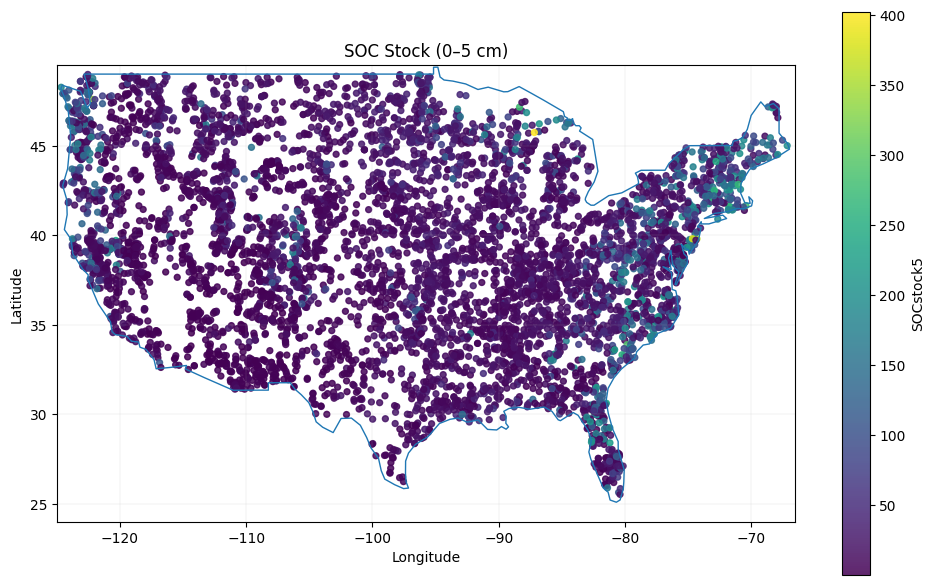

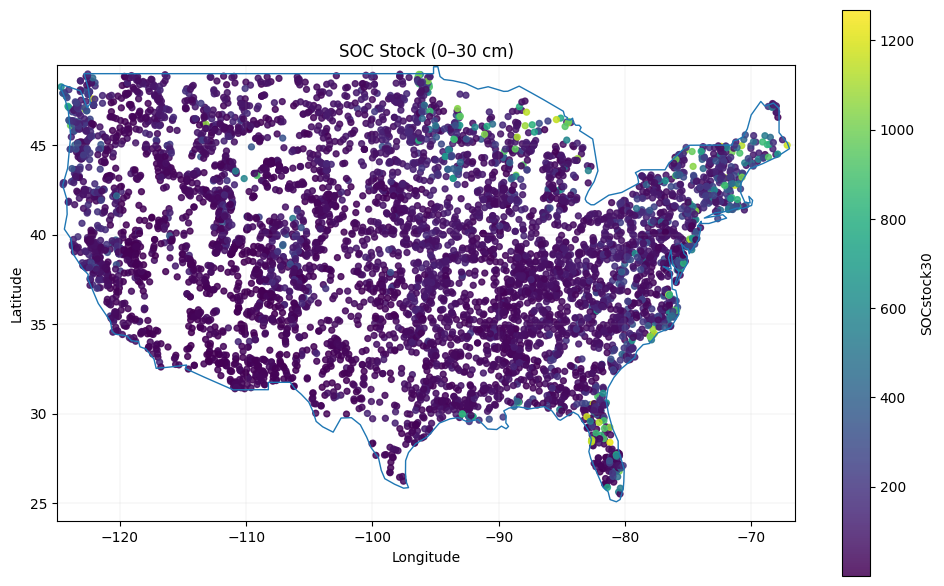

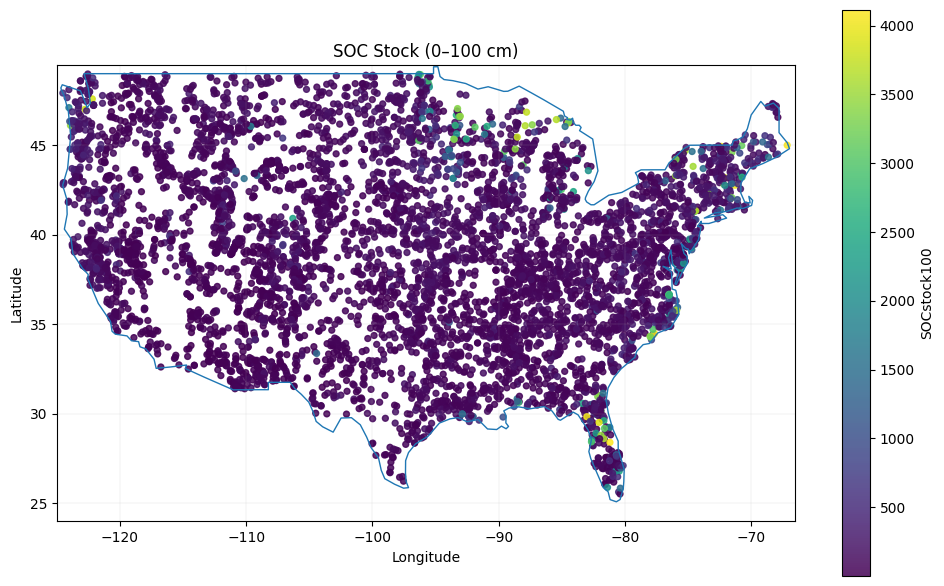

In [22]:
# If needed:
# %pip install geopandas shapely pyproj geodatasets

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import geodatasets

# --- USA boundary via geodatasets ---
import geopandas as gpd

world = gpd.read_file("ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp").to_crs("EPSG:4326")
usa = world[(world.get("ADMIN") == "United States of America") | (world.get("NAME") == "United States of America")]
# Some NE versions use ADMIN, others NAME / NAME_EN — handle both:
country_cols = [c for c in ["ADMIN", "NAME", "NAME_EN", "name"] if c in world.columns]
usa_mask = False
for c in country_cols:
    usa_mask = usa_mask | (world[c] == "United States of America") | (world[c] == "United States")
usa = world[usa_mask]

# --- Load SOC data ---
CSV_PATH = "RaCA_2.0/final_merged_df_RACA2.csv"  # adjust path if needed
df = pd.read_csv(CSV_PATH)
assert {"Lat","Lon","SOCstock5","SOCstock30","SOCstock100"}.issubset(df.columns)


print(df.shape)
# Points -> GeoDataFrame (WGS84)
pts = df.dropna(subset=["Lat","Lon"]).copy()
gdf = gpd.GeoDataFrame(
    pts,
    geometry=gpd.points_from_xy(pts["Lon"], pts["Lat"]),
    crs="EPSG:4326"
)

def plot_soc_map_usa(gdf, value_col, title):
    """Plot Lon/Lat points colored by `value_col` over a USA outline."""
    d = gdf.dropna(subset=[value_col]).copy()

    fig, ax = plt.subplots(figsize=(10, 6))
    usa.boundary.plot(ax=ax, linewidth=1)

    sc = ax.scatter(d.geometry.x, d.geometry.y, c=d[value_col], s=18, alpha=0.85)
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label(value_col)

    # zoom to CONUS (approx)
    ax.set_xlim([-125, -66.5])
    ax.set_ylim([24, 49.5])

    ax.set_title(title)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.grid(True, linewidth=0.3, alpha=0.4)
    plt.tight_layout()
    return fig, ax

# --- Use like this (uncomment to render) ---
plot_soc_map_usa(gdf, "SOCstock5",   "SOC Stock (0–5 cm)")
plot_soc_map_usa(gdf, "SOCstock30",  "SOC Stock (0–30 cm)")
plot_soc_map_usa(gdf, "SOCstock100", "SOC Stock (0–100 cm)")
plt.show()

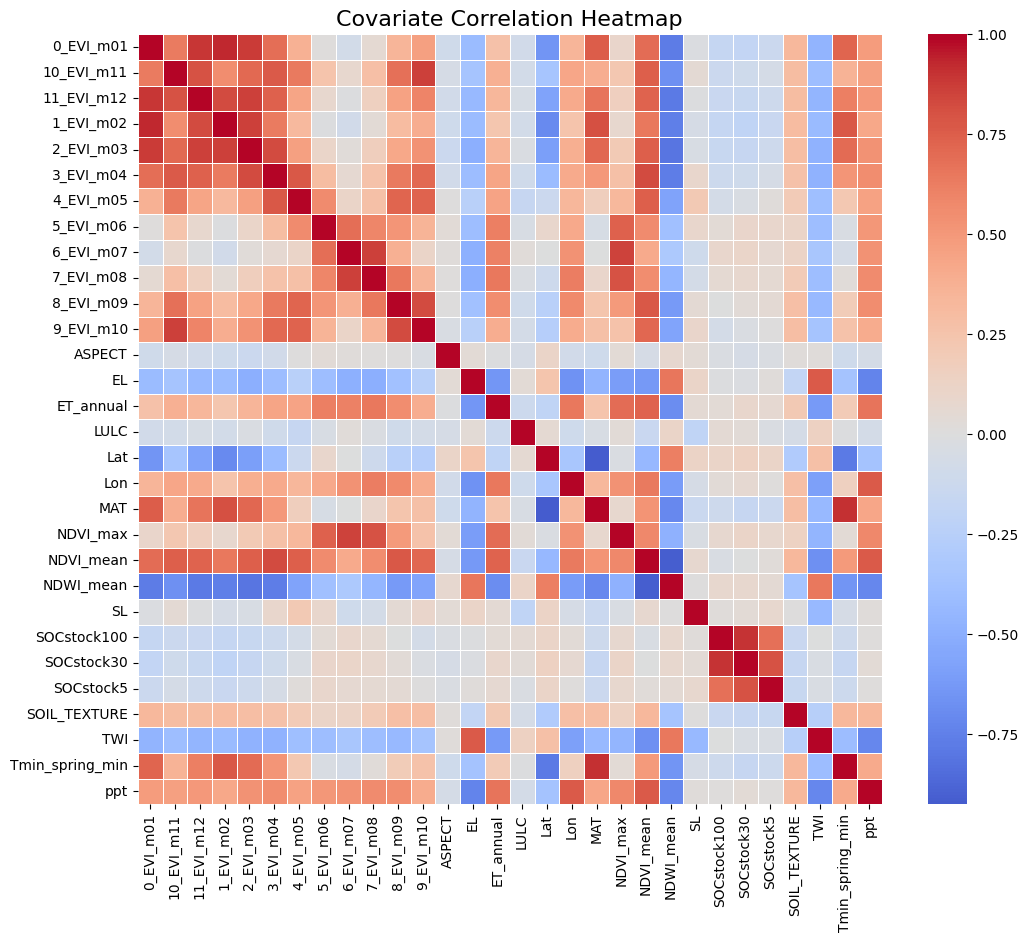

In [ ]:
from IPython.display import Image
Image(filename='interesting_old_covariate_heatmap.png') 

# It looks like EVI (Enhanced Vegetation Index) has good correlation for months 5-9 which is may - aug (Summer)
# Should I add something here or do you think that may be overfitting


### 2) GEE SCRIPT

In [ ]:
//I realized that since co-variates are year specific, a observation on 1/01/25 would get data for 2025 but really should be using 2024 data
//need to change to a better cutt-off


/************************************************************
 RaCA loader (ObservationDate) + covariates with IQR + export
 - Uses ObservationDate (M/d/yyyy or yyyy-MM-dd)
 - Rebuilds geometry from Lon/Lat
 - For each observation's calendar year, computes:
     mean, p25, p75, IQR (= p75 - p25) for time-varying covariates
 - Output is flat and ML-friendly
************************************************************/

// ==== CONFIG (edit if your column names differ) ====
var SITE_ID_FIELD = 'rcasiteid';
var LON_FIELD     = 'Lon';
var LAT_FIELD     = 'Lat';
var DATE_FIELD    = 'ObservationDate';   

// Sampling options
var SAMPLE_SCALE      = 250;    // MODIS-dominant scale
var USE_BUFFER_METERS = 0;      // >0: spatial median within buffer
// ================================================

// 0) Import your table via the UI "Imports" (variable name: `table`)
var raca = table;

// --- check ---
print('Raw ObservationDate sample (first 25):',
      raca.aggregate_array(DATE_FIELD).slice(0, 25));

/********* PREP: filter, rebuild geometry, IDs *********/

// keep rows with non-empty date + lon/lat
raca = raca.filter(ee.Filter.and(
  ee.Filter.notNull([DATE_FIELD, LON_FIELD, LAT_FIELD]),
  ee.Filter.neq(DATE_FIELD, ''),
  ee.Filter.neq(LON_FIELD, ''),
  ee.Filter.neq(LAT_FIELD, '')
));

// rebuild geometry from Lon/Lat (avoids empty MultiPoints)
raca = raca.map(function (f) {
  var lon = ee.Number.parse(f.get(LON_FIELD));
  var lat = ee.Number.parse(f.get(LAT_FIELD));
  return ee.Feature(ee.Geometry.Point([lon, lat]), f.toDictionary());
});

// ensure a site id
raca = raca.map(function (f) {
  var id = ee.Algorithms.If(f.propertyNames().contains(SITE_ID_FIELD),
                            f.get(SITE_ID_FIELD), f.id());
  return f.set(SITE_ID_FIELD, id);
});

/********* DATE PARSING (flexible) *********/
function parseDateFlexible(ds) {
  ds = ee.String(ds).trim();
  var hasSlash = ee.Number(ee.List(ds.split('/')).length()).gt(1);
  var hasDash  = ee.Number(ee.List(ds.split('-')).length()).gt(1);
  return ee.Algorithms.If(
    ds.length().gt(0),
    ee.Algorithms.If(
      hasSlash, ee.Date.parse('M/d/yyyy', ds),
      ee.Algorithms.If(hasDash, ee.Date.parse('yyyy-MM-dd', ds), null)
    ),
    null
  );
}

raca = raca.map(function (f) {
  var ds = f.get(DATE_FIELD);
  var d  = ee.Date(parseDateFlexible(ds));
  return ee.Algorithms.If(
    d,
    ee.Feature(f).set({'obs_date': d.millis(), 'obs_year': d.get('year')}),
    null
  );
}).filter(ee.Filter.notNull(['obs_year']));

print('Row count after load + parse:', raca.size());
print('Preview parsed rows:', raca.limit(5));

/********* MAP PREVIEW (optional) *********/
Map.centerObject(raca, 5);
Map.addLayer(raca, {color: 'red'}, 'RaCA points');

/************************************************************
 Covariates for EACH observation’s YEAR (with IQR) → export
************************************************************/

/**** REGION: CONUS ****/
var states = ee.FeatureCollection('TIGER/2018/States')
  .filter(ee.Filter.inList('STUSPS', [
    'AL','AZ','AR','CA','CO','CT','DE','FL','GA','ID','IL','IN','IA','KS','KY',
    'LA','ME','MD','MA','MI','MN','MS','MO','MT','NE','NV','NH','NJ','NM','NY',
    'NC','ND','OH','OK','OR','PA','RI','SC','SD','TN','TX','UT','VT','VA','WA',
    'WV','WI','WY'
  ]));
var CONUS = states.union().geometry();

/**** DATASETS ****/
// Terrain
var SRTM    = ee.Image('USGS/SRTMGL1_003').select('elevation'); // 30 m

// DAYMET (daily)
var DAYMET  = ee.ImageCollection('NASA/ORNL/DAYMET_V4');        // prcp, tmin, tmax (~1 km)

// MODIS vegetation & water
var MOD13Q1 = ee.ImageCollection('MODIS/006/MOD13Q1');          // NDVI/EVI (16-day, 250 m)
var MOD09A1 = ee.ImageCollection('MODIS/006/MOD09A1');          // SR (8-day, 500 m) → NDWI

// MODIS ET
var MOD16A2 = ee.ImageCollection('MODIS/006/MOD16A2');          // ET (8-day, 500 m)

// Static
var NLCD2011 = ee.ImageCollection('USGS/NLCD_RELEASES/2019_REL/NLCD')
  .filter(ee.Filter.eq('system:index', '2011'))
  .first().select('landcover').rename('LULC');
var SOIL_TEXTURE = ee.Image('OpenLandMap/SOL/SOL_TEXTURE-CLASS_USDA-TT_M/v02')
  .select('b0').rename('SOIL_TEXTURE'); // 0–5 cm layer

/**** HELPERS ****/
function yearRange(y){
  var s = ee.Date.fromYMD(y,1,1);
  return {start: s, end: s.advance(1,'year')};
}

function terrainFromDEM(dem){
  var terr = ee.Terrain.products(dem); // elevation, slope, aspect
  var slopeRad = terr.select('slope').multiply(Math.PI/180);
  var tanSlope = slopeRad.tan().updateMask(slopeRad.neq(0));
  var minEl = dem.reduceRegion({reducer: ee.Reducer.min(), geometry: CONUS, scale: 1000, maxPixels: 1e9}).get('elevation');
  var maxEl = dem.reduceRegion({reducer: ee.Reducer.max(), geometry: CONUS, scale: 1000, maxPixels: 1e9}).get('elevation');
  var accProxy = dem.unitScale(minEl, maxEl).focal_mean(3).multiply(1000).rename('acc_proxy');
  var twi = accProxy.add(1).log().subtract(tanSlope.log()).rename('TWI').updateMask(tanSlope);
  return terr.addBands(twi).select(['elevation','slope','aspect','TWI'], ['EL','SL','ASPECT','TWI']);
}

// Build a mean + p25/p75 + IQR stack from an ImageCollection (single band)
function statsFromCollection(ic, band, prefix){
  var sel   = ic.select(band);
  var mean  = sel.mean().rename(prefix + '_mean');
  var q     = sel.reduce(ee.Reducer.percentile([25,75])); // -> band_p25, band_p75
  // get names
  var p25n  = ee.String(band).cat('_p25');
  var p75n  = ee.String(band).cat('_p75');
  var iqr   = q.select(p75n).subtract(q.select(p25n)).rename(prefix + '_IQR');
  // rename percentile bands to prefix-based names for tidy output
  q = q.rename([prefix + '_p25', prefix + '_p75']);
  return mean.addBands(q).addBands(iqr);
}

function buildYearCovariates(year){
  year = ee.Number(year);
  var r   = yearRange(year);
  var dem = terrainFromDEM(SRTM);

  // --- Vegetation (NDVI/EVI) ---
  var veg = MOD13Q1.filterDate(r.start, r.end);
  var ndviStats = statsFromCollection(veg, 'NDVI', 'NDVI');
  var eviStats  = statsFromCollection(veg, 'EVI',  'EVI');

  // --- Water (NDWI) ---
  var ndwiIC = MOD09A1.filterDate(r.start, r.end)
    .select(['sur_refl_b04','sur_refl_b02'], ['green','nir'])
    .map(function(img){ return img.normalizedDifference(['green','nir']).rename('NDWI'); });
  var ndwiStats = statsFromCollection(ndwiIC, 'NDWI', 'NDWI');

  // --- ET (sum + percentiles across 8-day composites) ---
  var etIC   = MOD16A2.filterDate(r.start, r.end).select('ET');
  var etSum  = etIC.sum().rename('ET_sum');  // 1 kg/m² = 1 mm
  var etPerc = statsFromCollection(etIC, 'ET', 'ET').select(['ET_p25','ET_p75','ET_IQR']);
  var etAll  = etSum.addBands(etPerc);

  // --- DAYMET (daily) ---
  var daily   = DAYMET.filterDate(r.start, r.end);
  var prcpIC  = daily.select('prcp');                 // mm/day
  var tmeanIC = daily.map(function(img){
                  var tm = img.select('tmin').add(img.select('tmax')).divide(2).rename('tmean');
                  return tm.copyProperties(img, ['system:time_start']);
                });

  var pptSum   = prcpIC.sum().rename('ppt_sum');
  var pptPerc  = statsFromCollection(prcpIC, 'prcp',  'ppt').select(['ppt_p25','ppt_p75','ppt_IQR']);
  var matMean  = tmeanIC.mean().rename('MAT_mean');
  var matPerc  = statsFromCollection(tmeanIC, 'tmean', 'MAT').select(['MAT_p25','MAT_p75','MAT_IQR']);

  // Spring Tmin minimum (diagnostic)
  var springMin = DAYMET.filterDate(ee.Date.fromYMD(year,3,1), ee.Date.fromYMD(year,6,1))
      .select('tmin').min().rename('Tmin_spring_min');

  return ee.Image.cat([
    dem,                 // EL, SL, ASPECT, TWI
    ndviStats,           // NDVI_mean, NDVI_p25, NDVI_p75, NDVI_IQR
    eviStats,            // EVI_mean,  EVI_p25,  EVI_p75,  EVI_IQR
    ndwiStats,           // NDWI_mean, NDWI_p25, NDWI_p75, NDWI_IQR
    etAll,               // ET_sum, ET_p25, ET_p75, ET_IQR
    pptSum, pptPerc,     // ppt_sum, ppt_p25, ppt_p75, ppt_IQR
    matMean, matPerc,    // MAT_mean, MAT_p25, MAT_p75, MAT_IQR
    springMin,           // Tmin_spring_min
    NLCD2011,            // LULC
    SOIL_TEXTURE         // SOIL_TEXTURE
  ])
  .clip(CONUS)
  .set('year', year)
  .set('system:time_start', ee.Date.fromYMD(year,1,1).millis());
}

/********* SAMPLE BY OBSERVATION YEAR *********/
raca = raca.filterBounds(CONUS);

var YEARS_PRESENT = ee.List(raca.aggregate_array('obs_year')).distinct().sort();
print('Unique observation years:', YEARS_PRESENT);

function sampleForYear(y){
  y = ee.Number(y);
  var img = buildYearCovariates(y);
  var subset = raca.filter(ee.Filter.eq('obs_year', y));

  if (USE_BUFFER_METERS > 0){
    var buffered = subset.map(function(ft){ return ee.Feature(ft.buffer(USE_BUFFER_METERS)); });
    return img.reduceRegions({
      collection: buffered,
      reducer: ee.Reducer.median(),   // spatially robust within buffer
      scale: SAMPLE_SCALE
    }).map(function(ft){
      // set fields with simple assignments (avoid ES6 computed keys)
      ft = ft.set('covariate_year', y);
      ft = ft.set('observation_date_str', ft.get(DATE_FIELD));
      ft = ft.set(SITE_ID_FIELD, ft.get(SITE_ID_FIELD));
      return ft;
    });
  } else {
    return img.sampleRegions({
      collection: subset,
      scale: SAMPLE_SCALE,
      geometries: true
    }).map(function(ft){
      ft = ft.set('covariate_year', y);
      ft = ft.set('observation_date_str', ft.get(DATE_FIELD));
      ft = ft.set(SITE_ID_FIELD, ft.get(SITE_ID_FIELD));
      return ft;
    });
  }
}

var sampledAll = ee.FeatureCollection(YEARS_PRESENT.map(sampleForYear)).flatten();

print('Preview output (first 5):', sampledAll.limit(5));

/********* EXPORT *********/
Export.table.toDrive({
  collection: sampledAll,
  description: 'RaCA_covariates_with_IQR_by_ObservationYear',
  fileNamePrefix: 'RaCA_covariates_with_IQR_by_ObservationYear',
  fileFormat: 'CSV'
});

### 3) Exploratory Data Analysis

In [27]:
# --- EDA: print column names from the aggregated RaCA covariates CSV ---

import pandas as pd

# Update this path if your file lives elsewhere
csv_path = "RaCA_covariates_with_IQR_by_ObservationYear.csv"

# Read (low_memory=False to avoid dtype guessing issues on wide CSVs)
df = pd.read_csv(csv_path, low_memory=False)

# Basic info
print(f"Rows: {len(df):,} | Columns: {df.shape[1]:,}\n")

# Print column names in order
for i, c in enumerate(df.columns, start=1):
    print(f"{i:3d}. {c}")

Rows: 4,516 | Columns: 58

  1. system:index
  2. ASPECT
  3. EL
  4. ET_IQR
  5. ET_p25
  6. ET_p75
  7. ET_sum
  8. EVI_IQR
  9. EVI_mean
 10. EVI_p25
 11. EVI_p75
 12. Group
 13. LU
 14. LULC
 15. Lab_count
 16. Landuse
 17. Lat
 18. Lon
 19. MAT_IQR
 20. MAT_mean
 21. MAT_p25
 22. MAT_p75
 23. MO
 24. MOGr
 25. MOGrLU
 26. NDVI_IQR
 27. NDVI_mean
 28. NDVI_p25
 29. NDVI_p75
 30. NDWI_IQR
 31. NDWI_mean
 32. NDWI_p25
 33. NDWI_p75
 34. Non-R_SampleCount
 35. ObservationDate
 36. Region
 37. SL
 38. SOC_count
 39. SOC_thickness
 40. SOCstock100
 41. SOCstock30
 42. SOCstock5
 43. SOIL_TEXTURE
 44. Sample_count
 45. TWI
 46. Tmin_spring_min
 47. USE
 48. covariate_year
 49. obs_date
 50. obs_year
 51. observation_date_str
 52. ppt_IQR
 53. ppt_p25
 54. ppt_p75
 55. ppt_sum
 56. rcasiteid
 57. total_thickness
 58. .geo


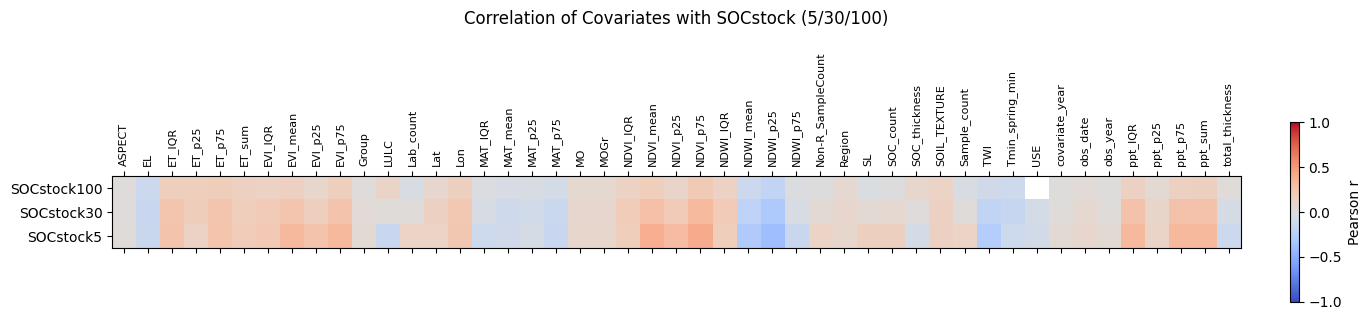

In [28]:
# --- Focused correlation heatmap: SOCstock targets only ---

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CSV_PATH = "RaCA_covariates_with_IQR_by_ObservationYear.csv"
TARGETS = ["SOCstock100", "SOCstock30", "SOCstock5"]

df = pd.read_csv(CSV_PATH, low_memory=False)

# Keep numeric columns
num = df.select_dtypes(include=["number"]).copy()

# Compute correlation matrix
corr = num.corr(method="pearson")

# Extract only rows corresponding to targets
target_corr = corr.loc[TARGETS].drop(columns=TARGETS, errors="ignore")

# ---- PLOT HEATMAP ----
fig, ax = plt.subplots(figsize=(14, 3))  # wide layout for readability
cax = ax.matshow(target_corr, cmap="coolwarm", vmin=-1, vmax=1)

fig.colorbar(cax, fraction=0.046, pad=0.04, label="Pearson r")

# Axis ticks
ax.set_xticks(range(len(target_corr.columns)))
ax.set_xticklabels(target_corr.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(TARGETS)))
ax.set_yticklabels(TARGETS, fontsize=10)

ax.set_title("Correlation of Covariates with SOCstock (5/30/100)", pad=20)
plt.tight_layout()
plt.show()

# ---- OPTIONAL: Print strongest correlations ----
# for tgt in TARGETS:
#     series = target_corr.loc[tgt].dropna()
#     top = series.abs().sort_values(ascending=False).head(10)
#     print(f"\nTop correlations for {tgt}:")
#     for var, val in series.loc[top.index].items():
#         print(f"{var:20s} r = {val:+.3f}")

### 4) Prliminary modeling

In [29]:
import re
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor  # for quantile models

# ---- I/O ----
CSV_PATH = "RaCA_covariates_with_IQR_by_ObservationYear.csv"

# ---- targets ----
TARGETS = ["SOCstock100", "SOCstock30", "SOCstock5"]

# ---- variables to always drop (ids / metadata / leakage) ----
DROP_COLS = {
    "system:index", ".geo", "rcasiteid",
    "obs_date", "obs_year", "observation_date_str",
    "ObservationDate", "covariate_year",  # duplicates / metadata
    # counts/collection design (avoid leakage)
    "Lab_count", "Sample_count", "Non-R_SampleCount", "SOC_count",
    # target-adjacent (keep as targets only)
    "SOC_thickness", "total_thickness",
}

# Optional: if you want to keep Region/LU but treat as categorical, remove them from DROP_COLS
# and add them to CATEGORICAL_KEEP below.
CATEGORICAL_KEEP = {"LULC", "LU", "Landuse", "USE", "MO", "MOGr", "MOGrLU", "Region"}

In [ ]:
df = pd.read_csv(CSV_PATH, low_memory=False)

print(f"Rows: {len(df):,}  |  Columns: {df.shape[1]}")
# print("First 5 columns:", list(df.columns[:5]))

# Should be around 6,000 rows so lost some in GEE script

Rows: 4,516  |  Columns: 58


In [32]:
cols = df.columns.tolist()

# helper predicates
def has_suffix(col, suf): return col.endswith(suf)
def any_suffix(col, sufs): return any(col.endswith(s) for s in sufs)

# identify groups by patterns
STATIC_NUM = {"EL", "SL", "ASPECT", "TWI", "SOIL_TEXTURE", "Tmin_spring_min"}
MEAN_KEEP  = {"NDVI_mean", "EVI_mean", "NDWI_mean", "MAT_mean", "ppt_sum", "ET_sum"}
IQR_KEEP   = {"NDVI_IQR", "EVI_IQR", "NDWI_IQR", "MAT_IQR", "ppt_IQR", "ET_IQR"}
PERC25     = {"NDVI_p25", "EVI_p25", "NDWI_p25", "MAT_p25", "ppt_p25", "ET_p25"}
PERC75     = {"NDVI_p75", "EVI_p75", "NDWI_p75", "MAT_p75", "ppt_p75", "ET_p75"}

# ensure existence (some rows/exports may differ)
STATIC_NUM = [c for c in STATIC_NUM if c in cols]
MEAN_KEEP  = [c for c in MEAN_KEEP  if c in cols]
IQR_KEEP   = [c for c in IQR_KEEP   if c in cols]
PERC25     = [c for c in PERC25     if c in cols]
PERC75     = [c for c in PERC75     if c in cols]

categoricals_present = [c for c in CATEGORICAL_KEEP if c in cols]
ignored_present      = [c for c in DROP_COLS if c in cols]

print("Static numeric:", STATIC_NUM)
print("Means:", MEAN_KEEP)
print("IQRs:", IQR_KEEP)
print("p25:", PERC25)
print("p75:", PERC75)
print("Categoricals:", categoricals_present)
print("To drop:", ignored_present)

# ---- Build feature lists ----
BASELINE_FEATURES = STATIC_NUM + MEAN_KEEP + categoricals_present

EXPANDED_FEATURES = STATIC_NUM + MEAN_KEEP + IQR_KEEP + PERC25 + PERC75 + categoricals_present

# Remove any targets or drop columns if accidentally present
BASELINE_FEATURES = [c for c in BASELINE_FEATURES if c not in TARGETS and c not in DROP_COLS]
EXPANDED_FEATURES = [c for c in EXPANDED_FEATURES if c not in TARGETS and c not in DROP_COLS]

print("\nBaseline feature count:", len(BASELINE_FEATURES))
print("Expanded feature count:", len(EXPANDED_FEATURES))

Static numeric: ['SOIL_TEXTURE', 'SL', 'EL', 'TWI', 'Tmin_spring_min', 'ASPECT']
Means: ['MAT_mean', 'ET_sum', 'EVI_mean', 'NDWI_mean', 'ppt_sum', 'NDVI_mean']
IQRs: ['EVI_IQR', 'NDWI_IQR', 'NDVI_IQR', 'ppt_IQR', 'MAT_IQR', 'ET_IQR']
p25: ['NDVI_p25', 'EVI_p25', 'ppt_p25', 'MAT_p25', 'ET_p25', 'NDWI_p25']
p75: ['EVI_p75', 'NDWI_p75', 'MAT_p75', 'NDVI_p75', 'ppt_p75', 'ET_p75']
Categoricals: ['USE', 'LULC', 'LU', 'MO', 'Region', 'MOGrLU', 'Landuse', 'MOGr']
To drop: ['.geo', 'obs_date', 'observation_date_str', 'Lab_count', 'system:index', 'SOC_thickness', 'total_thickness', 'Non-R_SampleCount', 'rcasiteid', 'covariate_year', 'obs_year', 'Sample_count', 'SOC_count', 'ObservationDate']

Baseline feature count: 20
Expanded feature count: 38


In [33]:
def make_preprocessor(feature_list):
    cat_cols = [c for c in feature_list if c in categoricals_present]
    num_cols = [c for c in feature_list if c not in cat_cols]
    pre = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(with_mean=False), num_cols),   # sparse-friendly
            ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
        ],
        remainder="drop",
        sparse_threshold=0.3
    )
    return pre, num_cols, cat_cols

pre_base, base_num, base_cat = make_preprocessor(BASELINE_FEATURES)
pre_exp,  exp_num,  exp_cat  = make_preprocessor(EXPANDED_FEATURES)

print("Baseline numeric:", base_num)
print("Baseline categorical:", base_cat)
print("Expanded numeric:", exp_num)
print("Expanded categorical:", exp_cat)

Baseline numeric: ['SOIL_TEXTURE', 'SL', 'EL', 'TWI', 'Tmin_spring_min', 'ASPECT', 'MAT_mean', 'ET_sum', 'EVI_mean', 'NDWI_mean', 'ppt_sum', 'NDVI_mean']
Baseline categorical: ['USE', 'LULC', 'LU', 'MO', 'Region', 'MOGrLU', 'Landuse', 'MOGr']
Expanded numeric: ['SOIL_TEXTURE', 'SL', 'EL', 'TWI', 'Tmin_spring_min', 'ASPECT', 'MAT_mean', 'ET_sum', 'EVI_mean', 'NDWI_mean', 'ppt_sum', 'NDVI_mean', 'EVI_IQR', 'NDWI_IQR', 'NDVI_IQR', 'ppt_IQR', 'MAT_IQR', 'ET_IQR', 'NDVI_p25', 'EVI_p25', 'ppt_p25', 'MAT_p25', 'ET_p25', 'NDWI_p25', 'EVI_p75', 'NDWI_p75', 'MAT_p75', 'NDVI_p75', 'ppt_p75', 'ET_p75']
Expanded categorical: ['USE', 'LULC', 'LU', 'MO', 'Region', 'MOGrLU', 'Landuse', 'MOGr']


In [34]:
# drop rows with missing targets
mask = df[TARGETS].notna().all(axis=1)
df_model = df.loc[mask].copy()

X_base = df_model[BASELINE_FEATURES]
X_exp  = df_model[EXPANDED_FEATURES]

y = df_model[TARGETS]

Xb_train, Xb_test, y_train, y_test = train_test_split(X_base, y, test_size=0.2, random_state=42)
Xe_train, Xe_test, _, _ = train_test_split(X_exp,  y, test_size=0.2, random_state=42)  # same split seed

In [35]:
def fit_eval_baseline(target):
    pipe = Pipeline([
        ("pre", pre_base),
        ("model", RandomForestRegressor(
            n_estimators=500,
            random_state=42,
            n_jobs=-1,
            max_depth=None
        ))
    ])
    pipe.fit(Xb_train, y_train[target])
    pred = pipe.predict(Xb_test)
    print(f"[Baseline] {target}: MAE={mean_absolute_error(y_test[target], pred):.3f}, "
          f"R2={r2_score(y_test[target], pred):.3f}")
    return pipe

baseline_models = {t: fit_eval_baseline(t) for t in TARGETS}

[Baseline] SOCstock100: MAE=69.127, R2=0.738
[Baseline] SOCstock30: MAE=36.115, R2=0.663
[Baseline] SOCstock5: MAE=15.029, R2=0.524


In [36]:
def fit_eval_expanded(target):
    pipe = Pipeline([
        ("pre", pre_exp),
        ("model", RandomForestRegressor(
            n_estimators=600,
            random_state=42,
            n_jobs=-1,
            max_depth=None
        ))
    ])
    pipe.fit(Xe_train, y_train[target])
    pred = pipe.predict(Xe_test)
    print(f"[Expanded] {target}: MAE={mean_absolute_error(y_test[target], pred):.3f}, "
          f"R2={r2_score(y_test[target], pred):.3f}")
    return pipe

expanded_models = {t: fit_eval_expanded(t) for t in TARGETS}

[Expanded] SOCstock100: MAE=73.446, R2=0.686
[Expanded] SOCstock30: MAE=39.982, R2=0.581
[Expanded] SOCstock5: MAE=15.921, R2=0.496


In [37]:
import numpy as np
import pandas as pd

# --- map mean -> IQR columns you want to perturb (climate + veg + water balance) ---
_MC_IQR_MAP = {
    "NDVI_mean": "NDVI_IQR",
    "EVI_mean":  "EVI_IQR",
    "NDWI_mean": "NDWI_IQR",
    "MAT_mean":  "MAT_IQR",
    "ppt_sum":   "ppt_IQR",   # using annual sum spread as scale proxy
    "ET_sum":    "ET_IQR",
}

# Optional ranges to clip after perturbation (keep signals physically plausible)
_CLIP_RANGES = {
    "NDVI_mean": (-1.0, 1.0),
    "EVI_mean":  (-1.0, 1.0),
    "NDWI_mean": (-1.0, 1.0),
}

def estimate_sigma_from_iqr(df_sub: pd.DataFrame, mapping=_MC_IQR_MAP) -> pd.DataFrame:
    """
    Approximate per-row std dev from IQR via sigma ≈ IQR / 1.349 (Normal assumption).
    Returns a DataFrame aligned to df_sub.index with a sigma column for each mean var present.
    """
    sigma = pd.DataFrame(index=df_sub.index)
    for mean_col, iqr_col in mapping.items():
        if mean_col in df_sub.columns and iqr_col in df_sub.columns:
            s = (df_sub[iqr_col].astype(float).clip(lower=0) / 1.349).replace([np.inf, -np.inf], np.nan)
            sigma[mean_col] = s.fillna(0.0)
    return sigma

def _clip_columns_inplace(X: pd.DataFrame, clip_ranges=_CLIP_RANGES):
    """Clip specified columns in-place to provided (lo, hi) ranges if present."""
    for col, (lo, hi) in clip_ranges.items():
        if col in X.columns:
            X[col] = X[col].clip(lo, hi)

def mc_predict_interval(
    trained_pipe,
    X_raw: pd.DataFrame,
    df_reference: pd.DataFrame,
    n_samples: int = 200,
    alpha: float = 0.10,
    mapping=_MC_IQR_MAP,
    clip_ranges=_CLIP_RANGES,
    seed: int = 42,
) -> pd.DataFrame:
    """
    Monte Carlo PIs by perturbing *_mean features using sigma from *_IQR (per-row).
    Returns a DataFrame with columns: ['mean', 'lo', 'hi'] aligned to X_raw.index.
    """
    idx = X_raw.index
    X0 = X_raw.copy()
    sigma = estimate_sigma_from_iqr(df_reference.loc[idx], mapping=mapping)
    preds = []

    rng = np.random.default_rng(seed)
    for _ in range(n_samples):
        Xs = X0.copy()
        # perturb only columns with available sigma
        for col in sigma.columns:
            if col in Xs.columns:
                noise = rng.normal(loc=0.0, scale=sigma[col].to_numpy())
                Xs[col] = Xs[col].to_numpy() + noise
        _clip_columns_inplace(Xs, clip_ranges)
        preds.append(trained_pipe.predict(Xs))

    preds = np.vstack(preds)  # [n_samples, n_rows]
    lo = np.quantile(preds, alpha/2, axis=0)
    hi = np.quantile(preds, 1 - alpha/2, axis=0)
    mean = preds.mean(axis=0)

    out = pd.DataFrame({"mean": mean, "lo": lo, "hi": hi}, index=idx)
    return out

# ===== Example usage on the EXPANDED model for SOCstock30 =====
tgt = "SOCstock30"

# Use the same rows as your Xe_test (df_model was built earlier in your notebook)
mc_df = mc_predict_interval(
    trained_pipe=expanded_models[tgt],
    X_raw=Xe_test,             # the expanded test features
    df_reference=df_model,     # to pull per-row IQRs for sigma
    n_samples=200,
    alpha=0.10,                # 90% interval
)

# Summary stats (fix: use np.median on numpy arrays)
pi_width = mc_df["hi"].to_numpy() - mc_df["lo"].to_numpy()
print(f"\n[MC] {tgt}")
print(f"  mean(pred)                 = {mc_df['mean'].mean():.2f}")
print(f"  PI90 median half-width     = {np.median(pi_width)/2:.2f}")
print(f"  PI90 mean  half-width      = {pi_width.mean()/2:.2f}")

# Optional: empirical coverage of PI90 against the true y_test
y_true = y_test[tgt].loc[mc_df.index]
coverage = np.mean((y_true.values >= mc_df['lo'].values) & (y_true.values <= mc_df['hi'].values))
print(f"  PI90 empirical coverage    = {coverage:.3f}")


[MC] SOCstock30
  mean(pred)                 = 98.89
  PI90 median half-width     = 20.38
  PI90 mean  half-width      = 19.80
  PI90 empirical coverage    = 0.170


In [38]:
def fit_quantile_models(X_train, y_train, alpha_lower=0.05, alpha_upper=0.95, use_expanded=True):
    pre = pre_exp if use_expanded else pre_base
    q_low  = Pipeline([
        ("pre", pre),
        ("model", GradientBoostingRegressor(loss="quantile", alpha=alpha_lower, random_state=42))
    ])
    q_high = Pipeline([
        ("pre", pre),
        ("model", GradientBoostingRegressor(loss="quantile", alpha=alpha_upper, random_state=42))
    ])
    mid = Pipeline([
        ("pre", pre),
        ("model", GradientBoostingRegressor(loss="squared_error", random_state=42))
    ])
    q_low.fit(X_train,  y_train)
    q_high.fit(X_train, y_train)
    mid.fit(X_train,    y_train)
    return q_low, mid, q_high

quantile_models = {}
for t in TARGETS:
    ql, mid, qh = fit_quantile_models(Xe_train, y_train[t], 0.05, 0.95, use_expanded=True)
    quantile_models[t] = (ql, mid, qh)

# Evaluate on test
for t in TARGETS:
    ql, mid, qh = quantile_models[t]
    y_pred_mid  = mid.predict(Xe_test)
    y_pred_lo   = ql.predict(Xe_test)
    y_pred_hi   = qh.predict(Xe_test)
    coverage = np.mean((y_test[t].values >= y_pred_lo) & (y_test[t].values <= y_pred_hi))
    print(f"[Quantiles] {t}: R2(mid)={r2_score(y_test[t], y_pred_mid):.3f}  MAE(mid)={mean_absolute_error(y_test[t], y_pred_mid):.3f}  "
          f"PI90 coverage={coverage:.3f}")

[Quantiles] SOCstock100: R2(mid)=0.670  MAE(mid)=81.332  PI90 coverage=0.872
[Quantiles] SOCstock30: R2(mid)=0.604  MAE(mid)=41.958  PI90 coverage=0.869
[Quantiles] SOCstock5: R2(mid)=0.473  MAE(mid)=17.019  PI90 coverage=0.874
